# 🚗 Car Price Prediction — Phase 1 & 2: Data Acquisition & EDA
**Dataset:** Kaggle Playground Series S4E9 — Used Car Price Regression  
**Goal:** Load, explore, and visualize 188K vehicle records to understand price drivers.

---

## 1. Install & Import Dependencies

In [2]:
# Run this first in Google Colab
!pip install -q kaggle pandas numpy matplotlib seaborn plotly scikit-learn xgboost lightgbm shap missingno

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d50',
    'axes.labelcolor':  '#c8cad6',
    'xtick.color':      '#8a8da0',
    'ytick.color':      '#8a8da0',
    'text.color':       '#c8cad6',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})

PALETTE = ['#4f8ef7', '#f7934f', '#4ff7b8', '#f74f6b', '#c74ff7', '#f7e14f']
sns.set_palette(PALETTE)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Dataset Download via Kaggle API

In [7]:
# ── Option A: Upload your kaggle.json API key ─────────────────────
from google.colab import files
print('Upload your kaggle.json file (from https://www.kaggle.com/settings > API > Create Token)')
# uploaded = files.upload()  # Uncomment to upload

# # Then run:
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c playground-series-s4e9 -p /content/data
# !unzip -q /content/data/playground-series-s4e9.zip -d /content/data/

# ── Option B: Manual upload ───────────────────────────────────────
# Download from: https://www.kaggle.com/competitions/playground-series-s4e9/data
# Then upload train.csv here:
uploaded = files.upload()


Upload your kaggle.json file (from https://www.kaggle.com/settings > API > Create Token)


Saving train.csv to train.csv


In [10]:
# ── Load data ─────────────────────────────────────────────────────
# Adjust path based on how you downloaded it
TRAIN_PATH = '/content/train.csv'   # Change if needed
TEST_PATH  = '/content/test.csv'

df     = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f'Train shape : {df.shape}')
print(f'Test shape  : {df_test.shape}')
df.head()

Train shape : (188533, 13)
Test shape  : (125690, 12)


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


## 3. Basic Data Audit

In [11]:
print('═' * 55)
print('DATASET OVERVIEW')
print('═' * 55)
print(f'Rows         : {df.shape[0]:,}')
print(f'Columns      : {df.shape[1]}')
print(f'Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('─── Data Types ───')
print(df.dtypes)
print()
print('─── Missing Values ───')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False))

═══════════════════════════════════════════════════════
DATASET OVERVIEW
═══════════════════════════════════════════════════════
Rows         : 188,533
Columns      : 13
Memory usage : 110.5 MB

─── Data Types ───
id               int64
brand           object
model           object
model_year       int64
milage           int64
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price            int64
dtype: object

─── Missing Values ───
             count    pct
clean_title  21419  11.36
fuel_type     5083   2.70
accident      2452   1.30


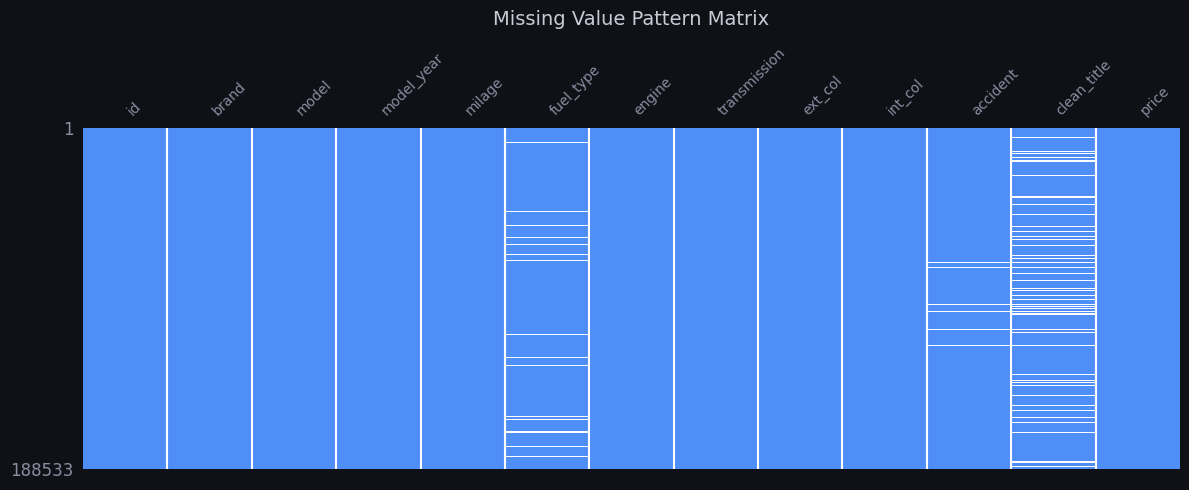

In [12]:
# Missing value matrix
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df, ax=ax, color=(0.31, 0.56, 0.97), fontsize=10)
ax.set_title('Missing Value Pattern Matrix', pad=15, fontsize=14, color='#c8cad6')
plt.tight_layout()
plt.show()

## 4. Target Variable Analysis: Price Distribution

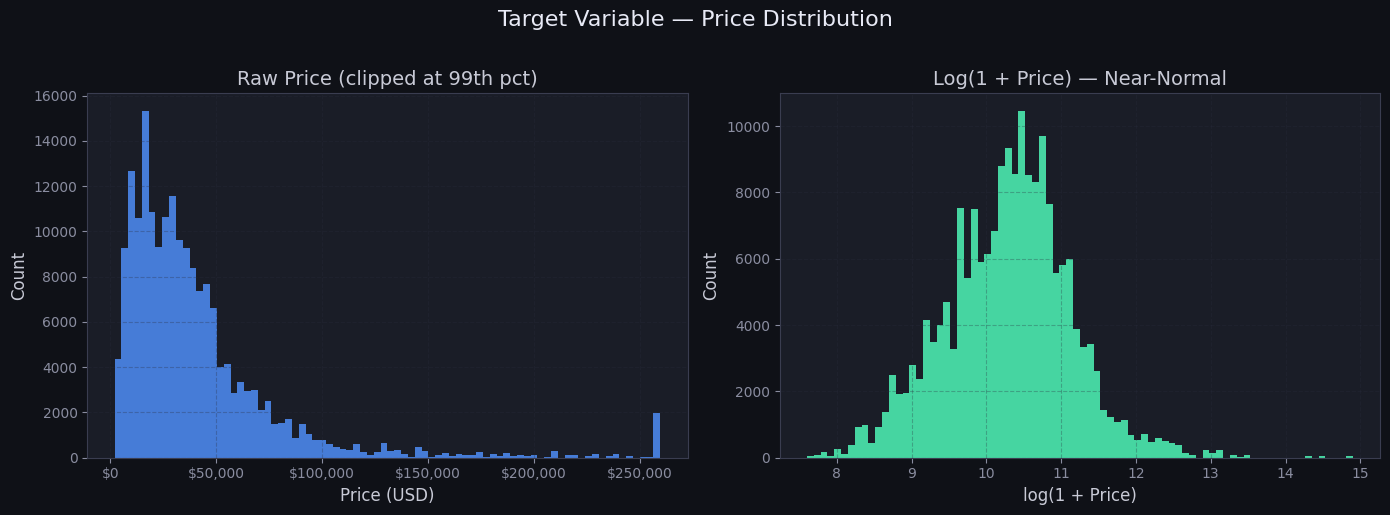

─── Price Statistics ───
count      $188,533.00
mean        $43,878.02
std         $78,819.52
min          $2,000.00
25%         $17,000.00
50%         $30,825.00
75%         $49,900.00
max      $2,954,083.00
Name: price, dtype: object


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable — Price Distribution', fontsize=16, color='#e8eaf6', y=1.02)

# Raw price
axes[0].hist(df['price'].clip(upper=df['price'].quantile(0.99)),
             bins=80, color='#4f8ef7', alpha=0.85, edgecolor='none')
axes[0].set_title('Raw Price (clipped at 99th pct)', color='#c8cad6')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# Log price
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=80, color='#4ff7b8', alpha=0.85, edgecolor='none')
axes[1].set_title('Log(1 + Price) — Near-Normal', color='#c8cad6')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('─── Price Statistics ───')
print(df['price'].describe().apply(lambda x: f'${x:,.2f}'))

## 5. Categorical Feature Analysis

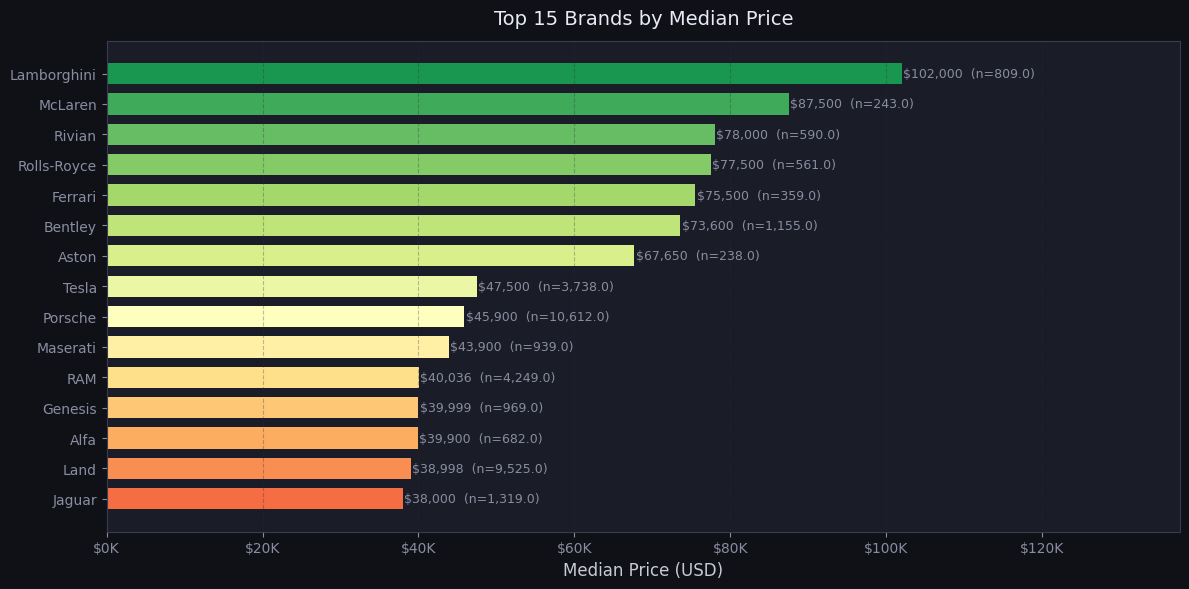

In [14]:
# Top 15 brands by median price
brand_stats = (
    df.groupby('brand')['price']
      .agg(['median', 'count'])
      .query('count >= 100')
      .sort_values('median', ascending=True)
      .tail(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(brand_stats)))
bars = ax.barh(brand_stats.index, brand_stats['median'], color=colors, edgecolor='none', height=0.7)

for bar, (_, row) in zip(bars, brand_stats.iterrows()):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${row["median"]:,.0f}  (n={row["count"]:,})',
            va='center', fontsize=9, color='#8a8da0')

ax.set_title('Top 15 Brands by Median Price', fontsize=14, color='#e8eaf6', pad=12)
ax.set_xlabel('Median Price (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, brand_stats['median'].max() * 1.35)
plt.tight_layout()
plt.show()

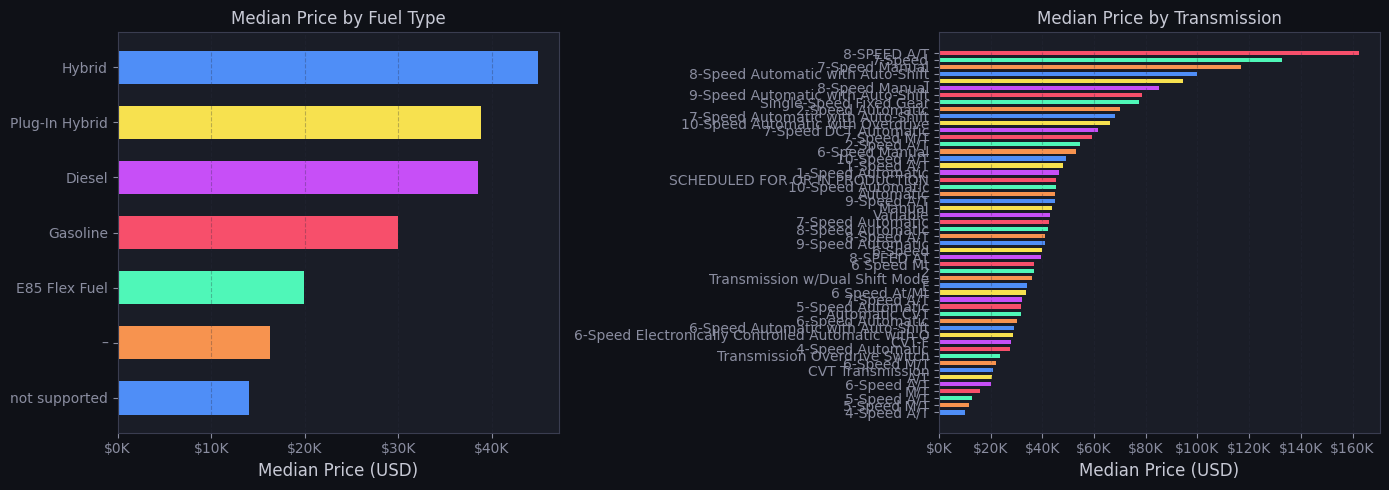

In [15]:
# Fuel type & transmission breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ['fuel_type', 'transmission'],
    ['Median Price by Fuel Type', 'Median Price by Transmission']):

    stats = df.groupby(col)['price'].median().sort_values(ascending=True)
    bars = ax.barh(stats.index, stats.values,
                   color=PALETTE[:len(stats)], edgecolor='none', height=0.6)
    ax.set_title(title, color='#c8cad6', fontsize=12)
    ax.set_xlabel('Median Price (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Numerical Feature Analysis

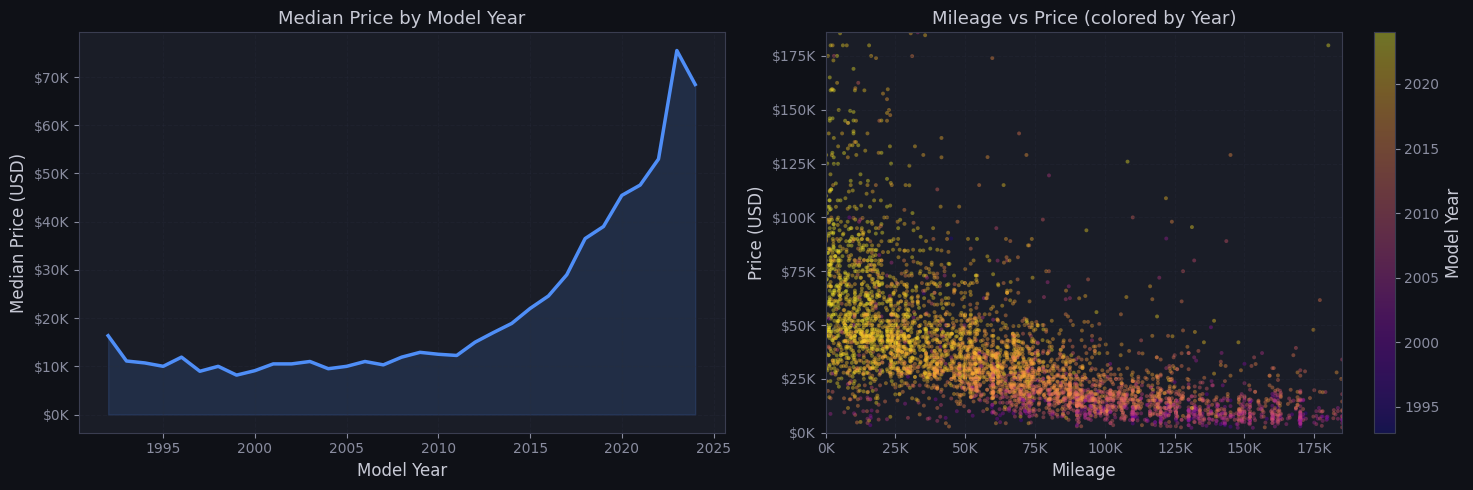

In [16]:
# Price vs Model Year
year_stats = df.groupby('model_year')['price'].median().reset_index()
year_stats = year_stats[year_stats['model_year'] >= 1990]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line: median price by year
axes[0].plot(year_stats['model_year'], year_stats['price'],
             color='#4f8ef7', linewidth=2.5, zorder=3)
axes[0].fill_between(year_stats['model_year'], year_stats['price'],
                     alpha=0.15, color='#4f8ef7')
axes[0].set_title('Median Price by Model Year', color='#c8cad6', fontsize=13)
axes[0].set_xlabel('Model Year')
axes[0].set_ylabel('Median Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].grid(True, alpha=0.3)

# Scatter: mileage vs price
sample = df.sample(min(5000, len(df)), random_state=42)
sc = axes[1].scatter(sample['milage'], sample['price'],
                     c=sample['model_year'], cmap='plasma',
                     alpha=0.4, s=8, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Model Year')
axes[1].set_title('Mileage vs Price (colored by Year)', color='#c8cad6', fontsize=13)
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlim(0, df['milage'].quantile(0.98))
axes[1].set_ylim(0, df['price'].quantile(0.98))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

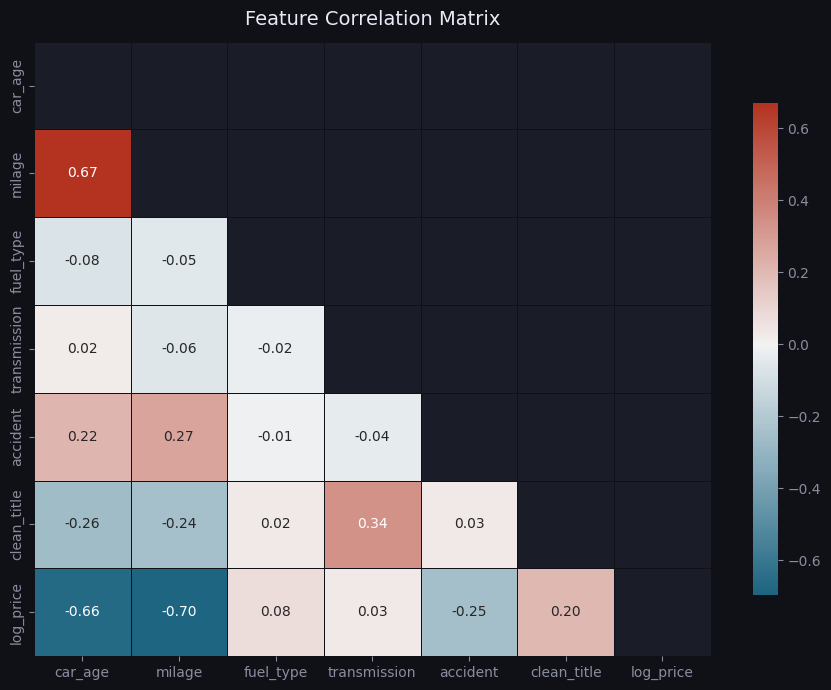

In [17]:
# Encode categoricals lightly for correlation
df_corr = df.copy()
df_corr['car_age'] = 2024 - df_corr['model_year']
df_corr['log_price'] = np.log1p(df_corr['price'])

for col in ['fuel_type', 'transmission', 'accident', 'clean_title']:
    if col in df_corr.columns:
        df_corr[col] = pd.factorize(df_corr[col].astype(str))[0]

num_cols = ['car_age', 'milage', 'fuel_type', 'transmission',
            'accident', 'clean_title', 'log_price']
num_cols = [c for c in num_cols if c in df_corr.columns]

corr = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 15, s=90, l=40, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, ax=ax, linewidths=0.4, linecolor='#0f1117',
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, color='#e8eaf6', pad=12)
plt.tight_layout()
plt.show()

## 8. Key EDA Takeaways

| Finding | Implication |
|---|---|
| Price is right-skewed | Use **log(1+price)** as the modeling target |
| Newer cars = higher price (strong trend) | `car_age = 2024 - model_year` is a key feature |
| Mileage negatively correlated with price | Include mileage + mileage² or log(mileage) |
| Luxury brands command 3-5× median price | Brand-tier encoding will capture non-linearity |
| Clean title & no accident = price premium | These boolean flags are high-signal |
| Missing values in fuel_type, engine, ext_col | Need imputation strategy in Phase 3 |

**→ Proceed to `02_Preprocessing_Features.ipynb`**

# 🚗 Car Price Prediction — Phase 3 & 4: Preprocessing & Feature Engineering
**Goal:** Clean raw data, extract signal from text fields, engineer domain-informed features, and export a model-ready dataset.

---

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d50', 'axes.labelcolor': '#c8cad6',
    'xtick.color': '#8a8da0', 'ytick.color': '#8a8da0',
    'text.color': '#c8cad6', 'grid.color': '#2a2d3e',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
})

TRAIN_PATH = '/content/train.csv'
TEST_PATH  = '/content/test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Keep IDs
train_ids = train['id'].copy() if 'id' in train.columns else None
test_ids  = test['id'].copy()  if 'id' in test.columns  else None

# Separate target
y_raw = train['price'].copy()
y = np.log1p(y_raw)  # Log-transform target

print(f'Train: {train.shape}, Test: {test.shape}')
print('✅ Data loaded')

Train: (188533, 13), Test: (125690, 12)
✅ Data loaded


## 1. Engine Feature Extraction

In [19]:
def parse_engine(engine_str):
    """Extract HP, displacement (L), and cylinder count from engine string."""
    result = {'hp': np.nan, 'displacement': np.nan, 'cylinders': np.nan}
    if pd.isna(engine_str):
        return result
    s = str(engine_str)

    # Horsepower
    hp_match = re.search(r'(\d+)\s*HP', s, re.IGNORECASE)
    if hp_match:
        result['hp'] = float(hp_match.group(1))

    # Displacement (e.g. 3.5L, 2.0L)
    disp_match = re.search(r'(\d+\.?\d*)\s*[Ll]', s)
    if disp_match:
        result['displacement'] = float(disp_match.group(1))

    # Cylinders (V6, V8, I4, 4-Cylinder, etc.)
    cyl_match = re.search(r'([IViv]?)(\d+)[-\s]?[Cc]yl', s)
    if cyl_match:
        result['cylinders'] = float(cyl_match.group(2))
    elif re.search(r'V(\d+)', s):
        result['cylinders'] = float(re.search(r'V(\d+)', s).group(1))
    elif re.search(r'I(\d+)', s):
        result['cylinders'] = float(re.search(r'I(\d+)', s).group(1))

    return result

# Apply to both train and test
for df in [train, test]:
    engine_parsed = df['engine'].apply(parse_engine).apply(pd.Series)
    df['engine_hp']   = engine_parsed['hp']
    df['engine_disp'] = engine_parsed['displacement']
    df['cylinders']   = engine_parsed['cylinders']

print('Engine HP sample:')
print(train[['engine', 'engine_hp', 'engine_disp', 'cylinders']].dropna().head(5))

Engine HP sample:
                                              engine  engine_hp  engine_disp  \
0       172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel        0.0          1.6   
1       252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel        0.0          3.9   
2  320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...        0.0          5.3   
3       420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel        0.0          5.0   
4       208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel        0.0          2.0   

   cylinders  
0        4.0  
1        8.0  
2        8.0  
3        8.0  
4        4.0  


## 2. Core Feature Engineering

In [20]:
CURRENT_YEAR = 2024

# Define luxury / budget brands from EDA knowledge
LUXURY_BRANDS = {
    'tier_ultra': {'Rolls-Royce', 'Lamborghini', 'Ferrari', 'Bugatti', 'McLaren', 'Bentley', 'Aston Martin'},
    'tier_luxury': {'Mercedes-Benz', 'BMW', 'Audi', 'Porsche', 'Lexus', 'Cadillac', 'Land Rover',
                    'Genesis', 'Maserati', 'Alfa Romeo', 'Volvo', 'Acura', 'Lincoln', 'Infiniti'},
    'tier_mid':    {'Toyota', 'Honda', 'Mazda', 'Subaru', 'Volkswagen', 'Hyundai', 'Kia',
                    'Chevrolet', 'Ford', 'Nissan', 'Jeep', 'Ram', 'Dodge', 'GMC', 'Buick'},
    'tier_budget': set()  # everything else
}

def assign_brand_tier(brand):
    brand = str(brand).strip()
    for tier, brands in LUXURY_BRANDS.items():
        if brand in brands:
            return tier
    return 'tier_budget'

TIER_MAP = {'tier_ultra': 4, 'tier_luxury': 3, 'tier_mid': 2, 'tier_budget': 1}

def engineer_features(df, is_train=True):
    df = df.copy()

    # ── Time features ──────────────────────────────────────────────
    df['car_age']     = CURRENT_YEAR - df['model_year'].clip(1900, CURRENT_YEAR)
    df['car_age_sq']  = df['car_age'] ** 2
    df['is_new']      = (df['car_age'] <= 2).astype(int)
    df['decade']      = (df['model_year'] // 10) * 10

    # ── Mileage features ───────────────────────────────────────────
    df['milage']      = df['milage'].clip(0)
    df['log_milage']  = np.log1p(df['milage'])
    df['km_per_year'] = df['milage'] / (df['car_age'] + 1)
    df['mileage_bin'] = pd.cut(df['milage'],
                                bins=[0, 10000, 30000, 60000, 100000, 150000, 999999],
                                labels=[0, 1, 2, 3, 4, 5]).astype(int)

    # ── Brand features ─────────────────────────────────────────────
    df['brand_tier']  = df['brand'].apply(assign_brand_tier)
    df['brand_tier_n']= df['brand_tier'].map(TIER_MAP)

    # ── Boolean flags ──────────────────────────────────────────────
    df['has_accident']   = (df['accident'].str.contains('accident', case=False, na=False)).astype(int)
    df['clean_title_flag']= (df['clean_title'].str.strip().str.lower() == 'yes').astype(int)

    # ── Engine ratios ──────────────────────────────────────────────
    df['hp_per_litre'] = df['engine_hp'] / (df['engine_disp'] + 1e-6)
    df['hp_age_ratio'] = df['engine_hp'] / (df['car_age'] + 1)

    # ── Text: EV detection ─────────────────────────────────────────
    df['is_electric'] = (
        df['fuel_type'].str.contains('electric', case=False, na=False) |
        df['engine'].str.contains('electric', case=False, na=False)
    ).astype(int)

    return df

train = engineer_features(train, is_train=True)
test  = engineer_features(test,  is_train=False)

print('✅ Feature engineering complete')
print(f'New feature count: {train.shape[1]} columns')

✅ Feature engineering complete
New feature count: 30 columns


## 3. Missing Value Imputation

In [21]:
from sklearn.impute import SimpleImputer

# Numerical: median impute (robust to outliers)
NUM_IMPUTE_COLS = ['engine_hp', 'engine_disp', 'cylinders', 'km_per_year', 'hp_per_litre', 'hp_age_ratio']

med_imputer = SimpleImputer(strategy='median')
train[NUM_IMPUTE_COLS] = med_imputer.fit_transform(train[NUM_IMPUTE_COLS])
test[NUM_IMPUTE_COLS]  = med_imputer.transform(test[NUM_IMPUTE_COLS])

# Categorical: fill with 'Unknown'
CAT_FILL_COLS = ['fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']
for df in [train, test]:
    for col in CAT_FILL_COLS:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

print('✅ Imputation complete')
print('Remaining nulls:', train[NUM_IMPUTE_COLS].isnull().sum().sum())

✅ Imputation complete
Remaining nulls: 0


## 4. Encoding & Final Feature Selection

In [22]:
from sklearn.preprocessing import LabelEncoder

# Columns to use in models
NUMERICAL_FEATURES = [
    'car_age', 'car_age_sq', 'log_milage', 'km_per_year', 'mileage_bin',
    'engine_hp', 'engine_disp', 'cylinders', 'hp_per_litre', 'hp_age_ratio',
    'brand_tier_n', 'has_accident', 'clean_title_flag', 'is_electric',
    'is_new', 'decade', 'model_year',
]

CATEGORICAL_FEATURES = ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col']

# Label-encode categoricals (tree models handle this fine)
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]]).astype(str)
    le.fit(combined)
    train[col + '_enc'] = le.transform(train[col].astype(str))
    test[col  + '_enc'] = le.transform(test[col].astype(str))
    label_encoders[col] = le

ENCODED_CAT_FEATURES = [c + '_enc' for c in CATEGORICAL_FEATURES]
ALL_FEATURES = NUMERICAL_FEATURES + ENCODED_CAT_FEATURES

X_train = train[ALL_FEATURES]
X_test  = test[ALL_FEATURES]

print(f'Final feature matrix: {X_train.shape}')
print('Features:', ALL_FEATURES)

Final feature matrix: (188533, 22)
Features: ['car_age', 'car_age_sq', 'log_milage', 'km_per_year', 'mileage_bin', 'engine_hp', 'engine_disp', 'cylinders', 'hp_per_litre', 'hp_age_ratio', 'brand_tier_n', 'has_accident', 'clean_title_flag', 'is_electric', 'is_new', 'decade', 'model_year', 'brand_enc', 'fuel_type_enc', 'transmission_enc', 'ext_col_enc', 'int_col_enc']


## 5. Outlier Removal

In [23]:
# Remove extreme price outliers (beyond 1.5 × IQR on log scale)
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
outlier_mask = (y >= lower) & (y <= upper)

X_train = X_train[outlier_mask]
y       = y[outlier_mask]
y_raw   = y_raw[outlier_mask]

print(f'Removed {(~outlier_mask).sum()} outliers ({(~outlier_mask).mean()*100:.2f}%)')
print(f'Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')

Removed 148 outliers (0.08%)
Training set: 188,385 samples, 22 features


## 6. Save Preprocessed Data

In [24]:
import joblib, os

os.makedirs('/content/processed', exist_ok=True)

X_train.to_parquet('/content/processed/X_train.parquet', index=False)
X_test.to_parquet('/content/processed/X_test.parquet',   index=False)
y.to_frame('log_price').to_parquet('/content/processed/y_train.parquet', index=False)

joblib.dump(label_encoders, '/content/processed/label_encoders.pkl')
joblib.dump(med_imputer,    '/content/processed/med_imputer.pkl')
joblib.dump(ALL_FEATURES,   '/content/processed/feature_names.pkl')

print('✅ Preprocessed data saved to /content/processed/')
print('\n→ Proceed to 03_Modeling.ipynb')

✅ Preprocessed data saved to /content/processed/

→ Proceed to 03_Modeling.ipynb


## Feature Engineering Summary

| Feature Group | New Features | Rationale |
|---|---|---|
| **Time** | `car_age`, `car_age_sq`, `is_new`, `decade` | Depreciation is non-linear |
| **Mileage** | `log_milage`, `km_per_year`, `mileage_bin` | Right-skew + usage intensity |
| **Engine** | `engine_hp`, `engine_disp`, `cylinders`, `hp_per_litre` | Performance signal |
| **Brand** | `brand_tier_n` (1–4) | Luxury premium encoding |
| **Condition** | `has_accident`, `clean_title_flag`, `is_electric` | Price adjustment factors |

**Target**: `log(1 + price)` — normalizes skew, improves model fit

# 🚗 Car Price Prediction — Phase 5 & 6: Modeling & Evaluation
**Models:** Linear Regression → Ridge → Random Forest → XGBoost → LightGBM (+ Ensemble)  
**Metrics:** RMSE (log scale), MAE (USD), R², MAPE

---

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, os, time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model   import LinearRegression, Ridge, Lasso
from sklearn.ensemble       import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import Pipeline
import xgboost  as xgb
import lightgbm as lgb
import shap

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d50', 'axes.labelcolor': '#c8cad6',
    'xtick.color': '#8a8da0', 'ytick.color': '#8a8da0',
    'text.color': '#c8cad6', 'grid.color': '#2a2d3e',
    'grid.linestyle': '--', 'grid.alpha': 0.5, 'font.family': 'DejaVu Sans',
})
PALETTE = ['#4f8ef7', '#f7934f', '#4ff7b8', '#f74f6b', '#c74ff7', '#f7e14f']

# ── Load preprocessed data ────────────────────────────────────────
X = pd.read_parquet('/content/processed/X_train.parquet')
y = pd.read_parquet('/content/processed/y_train.parquet')['log_price']
feature_names = joblib.load('/content/processed/feature_names.pkl')

print(f'X shape: {X.shape}, y shape: {y.shape}')
print('✅ Data loaded')

X shape: (188385, 22), y shape: (188385,)
✅ Data loaded


## 1. Train / Validation Split

In [26]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)
print(f'Train : {X_tr.shape[0]:,} | Val : {X_val.shape[0]:,}')

Train : 160,127 | Val : 28,258


## 2. Model Definitions

In [27]:
MODELS = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (α=10)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=4,
        max_features=0.6, n_jobs=-1, random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, n_jobs=-1, random_state=42,
        early_stopping_rounds=50, eval_metric='rmse'
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, n_jobs=-1, random_state=42,
        early_stopping_round=50, verbose=-1
    ),
}

print('Models registered:', list(MODELS.keys()))

Models registered: ['Linear Regression', 'Ridge (α=10)', 'Random Forest', 'XGBoost', 'LightGBM']


## 3. Training Loop with Metrics Collection

In [28]:
def evaluate(y_true_log, y_pred_log):
    """Return metrics in both log space and original USD space."""
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2       = r2_score(y_true_log, y_pred_log)

    y_true_usd = np.expm1(y_true_log)
    y_pred_usd = np.expm1(y_pred_log)
    mae_usd    = mean_absolute_error(y_true_usd, y_pred_usd)
    mape       = np.mean(np.abs((y_true_usd - y_pred_usd) / (y_true_usd + 1))) * 100

    return {'RMSE (log)': rmse_log, 'R²': r2, 'MAE ($)': mae_usd, 'MAPE (%)': mape}


results    = {}
trained    = {}
val_preds  = {}

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ')
    t0 = time.time()

    if name in ('XGBoost',):
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    elif name in ('LightGBM',):
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    else:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    metrics = evaluate(y_val, y_pred)
    metrics['train_time_s'] = round(time.time() - t0, 1)

    results[name]   = metrics
    trained[name]   = model
    val_preds[name] = y_pred

    print(f'RMSE={metrics["RMSE (log)"]:.4f}  R²={metrics["R²"]:.4f}  '
          f'MAE=${metrics["MAE ($)"]:.0f}  [{metrics["train_time_s"]}s]')

results_df = pd.DataFrame(results).T.sort_values('RMSE (log)')
print('\n', results_df.to_string())

Training Linear Regression... RMSE=0.5193  R²=0.6152  MAE=$17259  [0.6s]
Training Ridge (α=10)... RMSE=0.5193  R²=0.6152  MAE=$17258  [1.0s]
Training Random Forest... RMSE=0.4886  R²=0.6592  MAE=$16064  [191.6s]
Training XGBoost... RMSE=0.4842  R²=0.6654  MAE=$15967  [16.7s]
Training LightGBM... RMSE=0.4842  R²=0.6654  MAE=$15972  [8.1s]

                    RMSE (log)        R²       MAE ($)   MAPE (%)  train_time_s
LightGBM             0.484213  0.665396  15972.175894  36.926134           8.1
XGBoost              0.484221  0.665384  15967.460883  36.939049          16.7
Random Forest        0.488639  0.659250  16064.056049  37.292162         191.6
Ridge (α=10)         0.519262  0.615202  17258.240607  40.260268           1.0
Linear Regression    0.519264  0.615199  17258.501729  40.260052           0.6


## 4. Model Comparison Visualization

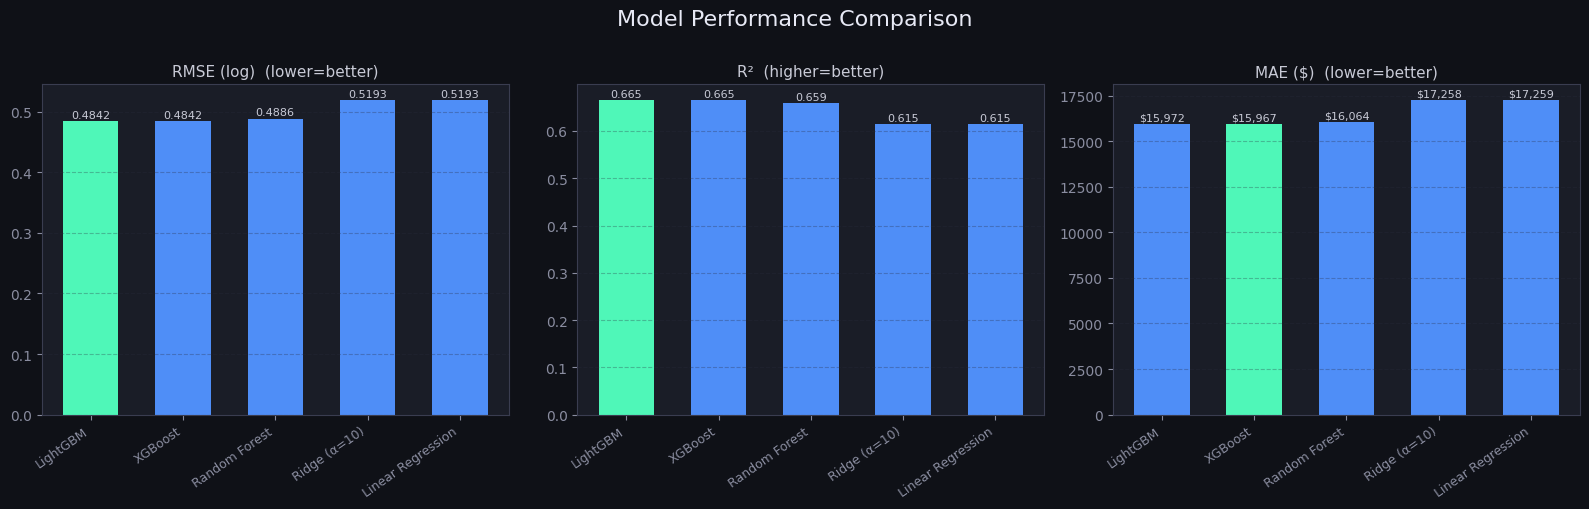

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, color='#e8eaf6', y=1.01)

metrics_to_plot = [('RMSE (log)', 'lower=better', True),
                   ('R²',         'higher=better', False),
                   ('MAE ($)',    'lower=better', True)]

model_names = results_df.index.tolist()
colors = PALETTE[:len(model_names)]

for ax, (metric, label, lower_better) in zip(axes, metrics_to_plot):
    vals = [results[m][metric] for m in model_names]
    best_idx = vals.index(min(vals) if lower_better else max(vals))
    bar_colors = [PALETTE[2] if i == best_idx else PALETTE[0] for i in range(len(model_names))]

    bars = ax.bar(range(len(model_names)), vals, color=bar_colors, edgecolor='none', width=0.6)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    ax.set_title(f'{metric}  ({label})', color='#c8cad6', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

    for i, (bar, v) in enumerate(zip(bars, vals)):
        fmt = f'{v:.4f}' if metric == 'RMSE (log)' else (f'{v:.3f}' if metric == 'R²' else f'${v:,.0f}')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                fmt, ha='center', fontsize=8, color='#c8cad6')

plt.tight_layout()
plt.show()

## 5. Best Model: Predicted vs Actual

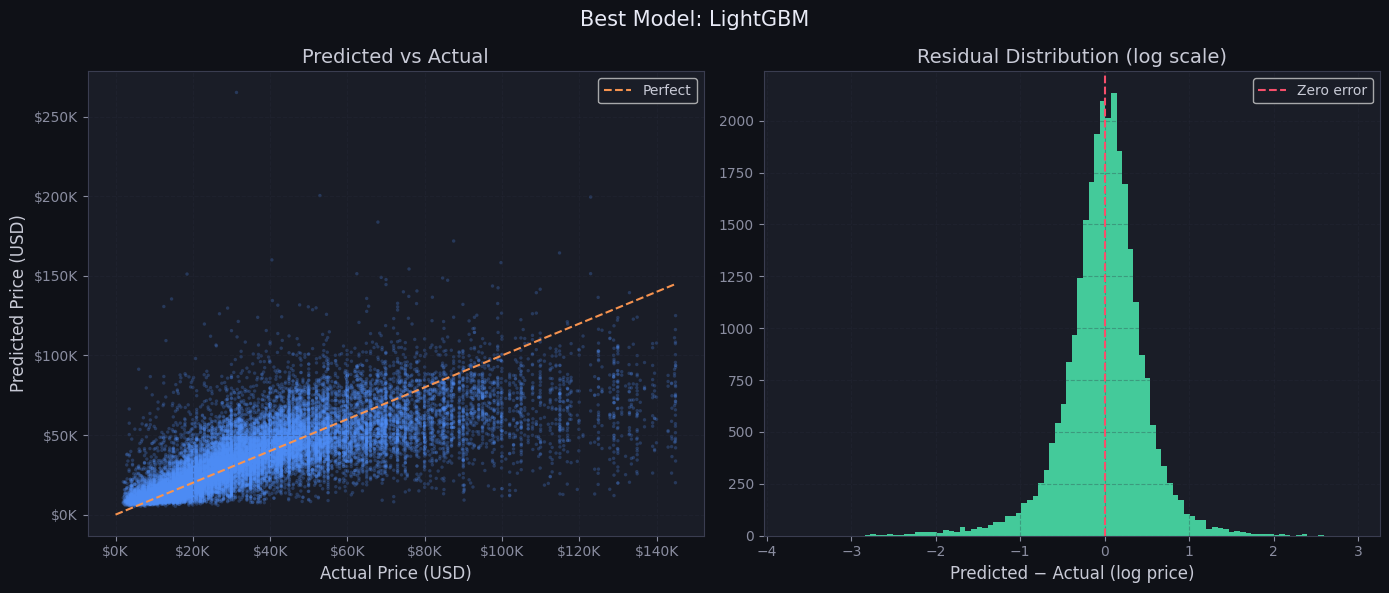

Best: LightGBM  |  R²=0.6654  |  MAE=$15,972


In [30]:
best_model_name = results_df.index[0]  # Lowest RMSE
best_preds_log  = val_preds[best_model_name]
best_preds_usd  = np.expm1(best_preds_log)
actual_usd      = np.expm1(y_val.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Best Model: {best_model_name}', fontsize=15, color='#e8eaf6')

# Predicted vs Actual scatter
clip_pct = np.percentile(actual_usd, 97)
mask_clip = actual_usd < clip_pct
axes[0].scatter(actual_usd[mask_clip], best_preds_usd[mask_clip],
                alpha=0.25, s=6, color='#4f8ef7', edgecolors='none')
lim = clip_pct
axes[0].plot([0, lim], [0, lim], '--', color='#f7934f', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Predicted vs Actual')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual distribution
residuals = best_preds_log - y_val.values
axes[1].hist(residuals, bins=100, color='#4ff7b8', alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='#f74f6b', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].set_title('Residual Distribution (log scale)')
axes[1].set_xlabel('Predicted − Actual (log price)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best: {best_model_name}  |  R²={results[best_model_name]["R²"]:.4f}  |  MAE=${results[best_model_name]["MAE ($)"]:,.0f}')

## 6. SHAP Feature Importance

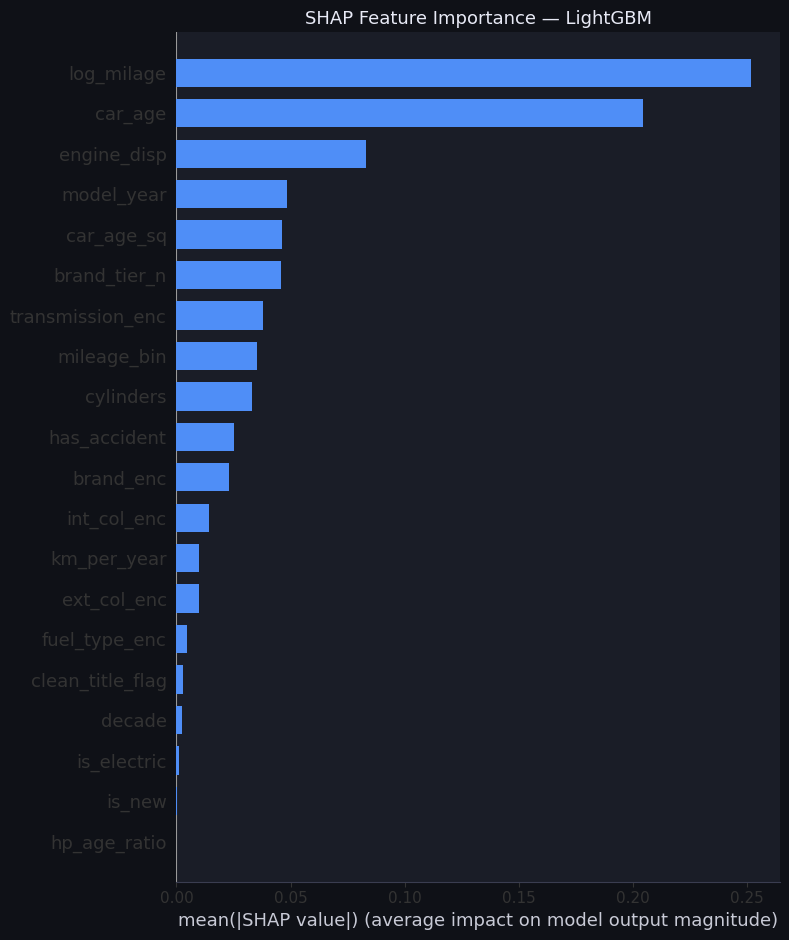

In [31]:
# Use LightGBM or XGBoost SHAP (tree explainer)
shap_model_name = 'LightGBM' if 'LightGBM' in trained else best_model_name
shap_model = trained[shap_model_name]

sample_size = min(2000, len(X_val))
X_shap = X_val.sample(sample_size, random_state=42)

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False, color='#4f8ef7')
plt.title(f'SHAP Feature Importance — {shap_model_name}', fontsize=13, color='#e8eaf6')
plt.tight_layout()
plt.show()

## 7. Weighted Ensemble

In [32]:
# Simple weighted blend: weight by 1/RMSE
ensemble_models = ['XGBoost', 'LightGBM', 'Random Forest']
ensemble_models = [m for m in ensemble_models if m in val_preds]

rmse_weights = np.array([1.0 / results[m]['RMSE (log)'] for m in ensemble_models])
rmse_weights /= rmse_weights.sum()

ensemble_pred = sum(w * val_preds[m] for m, w in zip(ensemble_models, rmse_weights))
ens_metrics = evaluate(y_val, ensemble_pred)

print('Ensemble weights:', dict(zip(ensemble_models, rmse_weights.round(3))))
print(f'Ensemble  RMSE={ens_metrics["RMSE (log)"]:.4f}  R²={ens_metrics["R²"]:.4f}  MAE=${ens_metrics["MAE ($)"]:.0f}')
print(f'{best_model_name}  RMSE={results[best_model_name]["RMSE (log)"]:.4f}  R²={results[best_model_name]["R²"]:.4f}')

Ensemble weights: {'XGBoost': np.float64(0.334), 'LightGBM': np.float64(0.334), 'Random Forest': np.float64(0.331)}
Ensemble  RMSE=0.4835  R²=0.6664  MAE=$15934
LightGBM  RMSE=0.4842  R²=0.6654


## 8. Save Final Model

In [33]:
os.makedirs('/content/models', exist_ok=True)

# Save all trained models
for name, model in trained.items():
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(model, f'/content/models/{fname}.pkl')

joblib.dump(feature_names, '/content/models/feature_names.pkl')
results_df.to_csv('/content/models/model_results.csv')

print('✅ All models saved to /content/models/')
for name in trained:
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    print(f'  {fname}.pkl')

print('\n→ Proceed to app.py for Streamlit deployment')

✅ All models saved to /content/models/
  linear_regression.pkl
  ridge_α=10.pkl
  random_forest.pkl
  xgboost.pkl
  lightgbm.pkl

→ Proceed to app.py for Streamlit deployment


## Results Summary

| Model | Strength | Weakness |
|---|---|---|
| Linear Regression | Fast, interpretable | Underfits non-linear relationships |
| Ridge | Handles multicollinearity | Still linear |
| Random Forest | Robust, no scaling needed | Slow to train, memory-heavy |
| **XGBoost** | **Excellent accuracy, fast** | **Needs careful tuning** |
| **LightGBM** | **Fastest + best on large data** | **Slightly overfit-prone** |
| **Ensemble** | **Most robust** | **Slower inference** |